In [82]:
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import joblib




In [30]:
# Load the movies_scaled_dummies.csv file from the data folder
movies_scaled = pd.read_csv('../data/movies_scaled_dummies.csv')
movies_scaled.head()

,Budget,Gross,Release Date,Runtime,Rating,Rating Count,Net Profit,ROI,Genre_Frequency,MPAA Rating_G,...,Genre_Family,Genre_Fantasy,Genre_History,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
0,-1.284438,296000000.0,10,-1.100607,-1.146270,-0.831512,288500000.0,38.466667,0.051282,0,...,0,0,0,0,0,1,0,0,0,0
1,-1.284438,145793296.0,12,-0.832114,0.549913,-0.776143,138293296.0,18.439106,0.185404,0,...,0,0,0,0,0,0,0,0,0,0
2,-1.191530,71079915.0,7,-0.787365,0.323756,-0.775063,58079915.0,4.467686,0.031558,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.174637,161001698.0,12,1.226329,0.323756,-0.775063,147001698.0,10.500121,0.015779,0,...,0,0,0,0,0,0,0,0,1,0
4,-1.157745,84431625.0,4,-0.474124,0.662992,-0.742398,69431625.0,4.628775,0.110454,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
# Split the data into 70% training and 30% testing sets
# We can't predict Gross with ROI or Net Profits so we will use all three as potential target variables

yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled[yfeatures]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [48]:
# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross, ROI, and Net Profit revenue on the test set
y_pred = rf.predict(X_test)

In [49]:
# Show training R^2 score
train_r2 = r2_score(y_train, rf.predict(X_train))

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")


Training R^2 Score: 0.9318
Mean Squared Error: 14104968386754992.0000
Mean Absolute Error: 71698611.8826
R^2 Score: 0.4946


Not The best model. Lets try it with just Gross as a prediction

In [34]:
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
# Show training R^2 score
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.9437
Mean Squared Error: 21991735966637016.0000
Mean Absolute Error: 109383980.4638
R^2 Score: 0.6134


In [35]:
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['ROI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the ROI revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.9167
Mean Squared Error: 9.5475
Mean Absolute Error: 1.9036
R^2 Score: 0.6731


In [36]:
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Net Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the Net profit revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.9290
Mean Squared Error: 19181925976528556.0000
Mean Absolute Error: 102125406.4676
R^2 Score: 0.5286


Comparing the differnt calculations we can use for y features, ROI seems to have the best corrilation when using random forest. ROI can also be used to calculate the gross. So ROI will be used in the next tests.

Now we can see how Xboost compairs using ROI

In [37]:

# Create and fit an XGBoost Regressor model on the training set
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = xgb.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Show training R^2 score
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"XGBoost Mean Squared Error: {mse:.4f}")
print(f"XGBoost Mean Absolute Error: {mae:.4f}")
print(f"XGBoost R^2 : {r2:.4f}")

Training R^2 Score: 0.9290
XGBoost Mean Squared Error: 22415576519122976.0000
XGBoost Mean Absolute Error: 108542072.2303
XGBoost R^2 : 0.4491


XGBoost does not out preform random forest regression with an R squared of 0.44 vs. .67

Lets go back to the random forest model and look at hyperparameters

In [38]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30, 40, 50, 60, 70],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
}

# Initialize Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


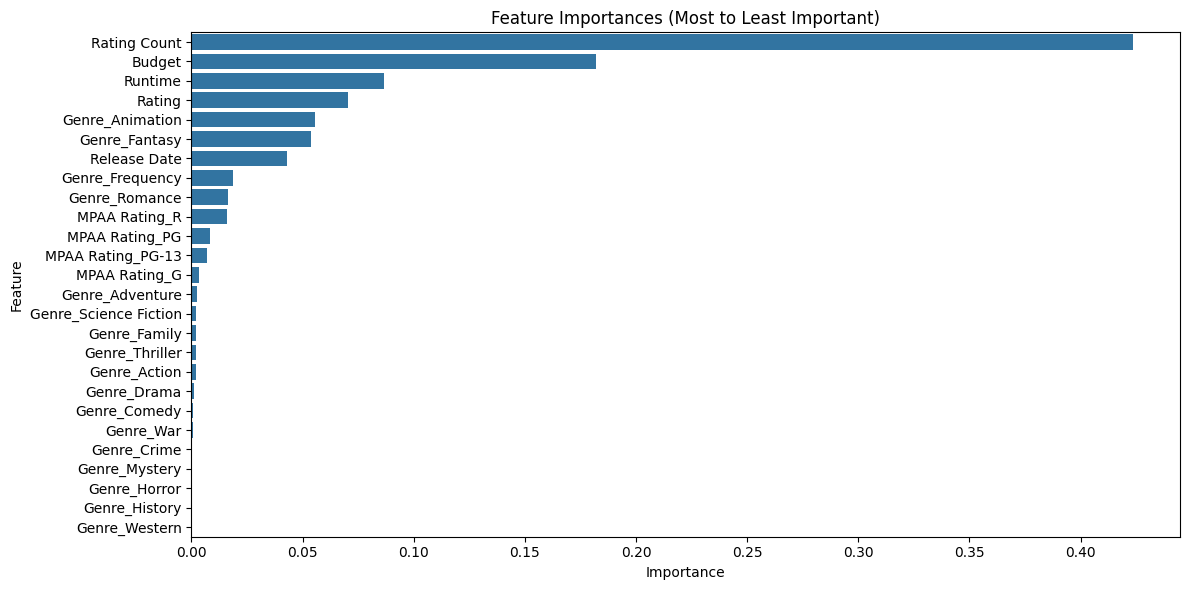

In [39]:
# Get feature importances from the best estimator after grid search
best_rf = grid_search.best_estimator_
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
plt.title('Feature Importances (Most to Least Important)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Based on best features, Rating Count, Budget, Runtime, Rating, Release Date, Genre_Frequency, Genre_animation, and Genere_Fantasy will be used for the model

In [41]:
# Remake the ROI test and train sets. using the most important features
features = [
    "Budget",
    "Rating Count",
    "Runtime",
    "Rating",
    "Release Date",
    "Genre_Frequency"
   ]


X = movies_scaled[features]
y = movies_scaled['ROI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [45]:
param = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 2
}

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(**param,random_state=42)
rf.fit(X_train, y_train)
# Predict the ROI revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

train_r2 = r2_score(y_train, rf.predict(X_train))

print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.8192
Mean Squared Error: 9.1275
Mean Absolute Error: 1.8549
R^2 Score: 0.6875


In [66]:
# Perform K-Fold cross validation on the Random Forest model
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=42)
rf = RandomForestRegressor(**param, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')

print(f"K-Fold Cross Validation R^2 Scores: {cv_scores}")
print(f"Mean R^2 Score: {cv_scores.mean():.4f}")

K-Fold Cross Validation R^2 Scores: [0.79938901 0.54390547 0.51090489 0.57491842 0.49554826 0.23842192
 0.59219181 0.61177751 0.54595495 0.59903249]
Mean R^2 Score: 0.5512


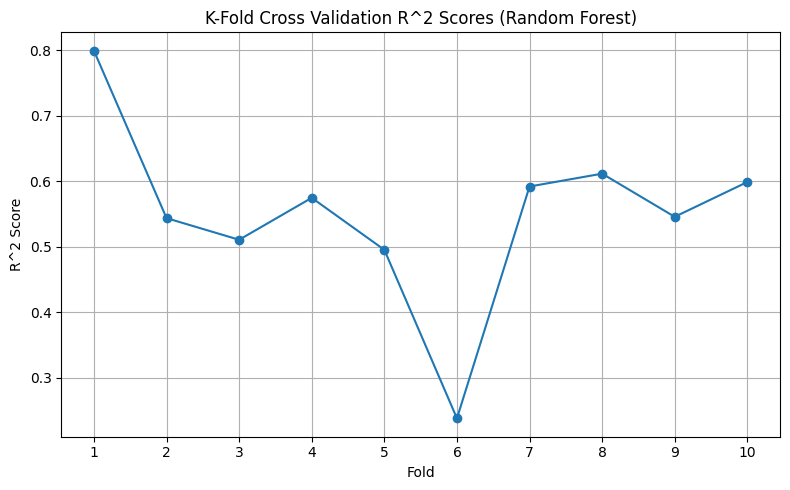

In [67]:
# Plot K-Fold Cross Validation R^2 Scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o')
plt.title('K-Fold Cross Validation R^2 Scores (Random Forest)')
plt.xlabel('Fold')
plt.ylabel('R^2 Score')
plt.xticks(range(1, len(cv_scores) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

Now we will try a linear regression model using only the linear variables

In [50]:


# Create and fit a Linear Regression model on the training set
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict the target variables on the test set
y_pred = lr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Show training R^2 score for Linear Regression
train_r2 = r2_score(y_train, lr.predict(X_train))

print(f"Training Linear Regression R^2 Score: {train_r2:.4f}")
print(f"Linear Regression Mean Squared Error: {mse:.4f}")
print(f"Linear Regression Mean Absolute Error: {mae:.4f}")
print(f"Linear Regression R^2 Score: {r2:.4f}")

Training Linear Regression R^2 Score: 0.4694
Linear Regression Mean Squared Error: 15443904473039450.0000
Linear Regression Mean Absolute Error: 73395377.9747
Linear Regression R^2 Score: 0.4180


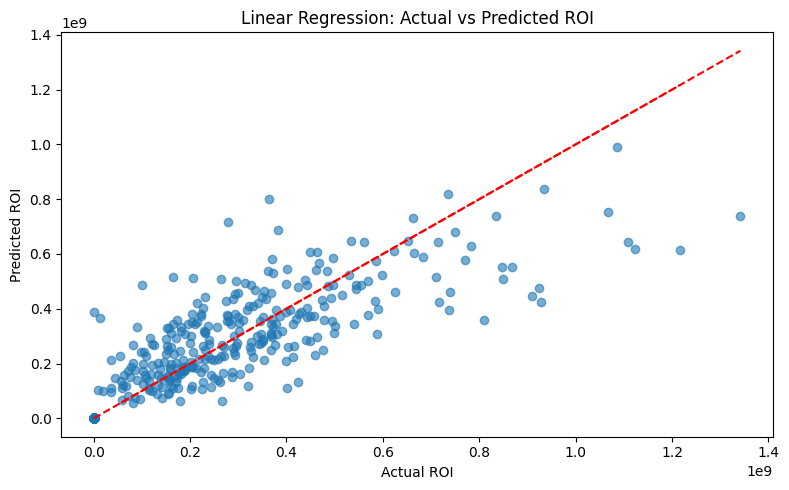

In [51]:
# Plot actual vs predicted values for the linear regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.title("Linear Regression: Actual vs Predicted ROI")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.tight_layout()
plt.show()

In [52]:
# Remake the ROI test and train sets. using the most important features
features = [
    "Budget",
    "Rating Count",
    "Runtime",
    "Rating",
    "Release Date",
    "Genre_Frequency"
   ]

X = movies_scaled[features]
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [55]:


# Create and fit a Linear Regression model on the training set
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict the target variables on the test set
y_pred = lr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, lr.predict(X_train))

print(f"Training Linear Regression R^2 Score: {train_r2:.4f}")
print(f"Linear Regression Mean Squared Error: {mse:.4f}")
print(f"Linear Regression Mean Absolute Error: {mae:.4f}")
print(f"Linear Regression R^2 Score: {r2:.4f}")

Training Linear Regression R^2 Score: 0.5562
Linear Regression Mean Squared Error: 25211101829192488.0000
Linear Regression Mean Absolute Error: 115733159.4700
Linear Regression R^2 Score: 0.5569


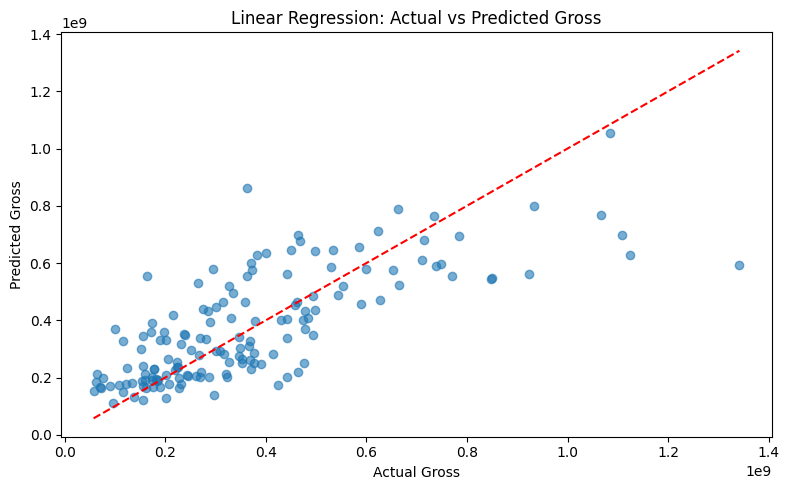

In [56]:
# Plot actual vs predicted values for the linear regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("Linear Regression: Actual vs Predicted Gross")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.tight_layout()
plt.show()

The Linear regression predicting Gross preforms better the ROI. However compared to the Random Forest model, it has a R squared value of only .55. Next we will try SVR modeling

In [79]:
# Remake the ROI test and train sets. using the most important features
features = [
    "Budget",
    "Rating Count",
    "Runtime",
    "Rating",
    "Release Date",
    "Genre_Frequency"
   ]

X = movies_scaled[features]
y = movies_scaled['ROI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [80]:

# Create and fit a Support Vector Regressor model on the training set
svr = SVR()
svr.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = svr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, svr.predict(X_train))

print(f"Training SVR R^2 Score: {train_r2:.4f}")
print(f"SVR Mean Squared Error: {mse:.4f}")
print(f"SVR Mean Absolute Error: {mae:.4f}")
print(f"SVR R^2 Score: {r2:.4f}")

Training SVR R^2 Score: 0.1047
SVR Mean Squared Error: 26.4932
SVR Mean Absolute Error: 2.5877
SVR R^2 Score: 0.0930


Support Vector Machine preforms extremely poor. We will create and export a random forest model based on the chosen parameters becasue it preforms best.

In [89]:
# Load the StandardScaler from a pickle file
scaler = joblib.load('../data/standard_scaler.pkl')

features = [
    "Budget",
    "Rating Count",
    "Runtime",
    "Rating",
    "Release Date",
    "Genre_Frequency"
]

X_full = movies_scaled[features]
y_full = movies_scaled['ROI']

# Create pipeline with StandardScaler and RandomForestRegressor
pipeline = Pipeline([
    ('scaler', scaler),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2, random_state=42))
])

# Fit pipeline
pipeline.fit(X_full, y_full)

# Predict
train_r2 = r2_score(y_full, pipeline.predict(X_full))
print("Random Forest model trained on the full dataset.")
print(f"Training R^2 Score: {train_r2:.4f}")

Random Forest model trained on the full dataset.
Training R^2 Score: 0.8548


In [ ]:
# Export the trained pipeline to a pickle file
joblib.dump(pipeline, '../data/random_forest_pipeline.pkl')
print("Pipeline exported to ../data/random_forest_pipeline.pkl")